In [2]:
import pandas as pd
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gmean


In [3]:
DATA_DIR = '../../Data/splitting_data/used'
splitting_file = os.path.join(DATA_DIR, 'ACl_FILTERED_DATA_04.csv')

In [4]:
data = pd.read_csv(splitting_file)

In [5]:
data_ninety = data.query('takeoff_ang_epi >= 90')

/tmp/ipykernel_3893357/1692933429.py:126: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0, window_df['n'].max() * 1.15)


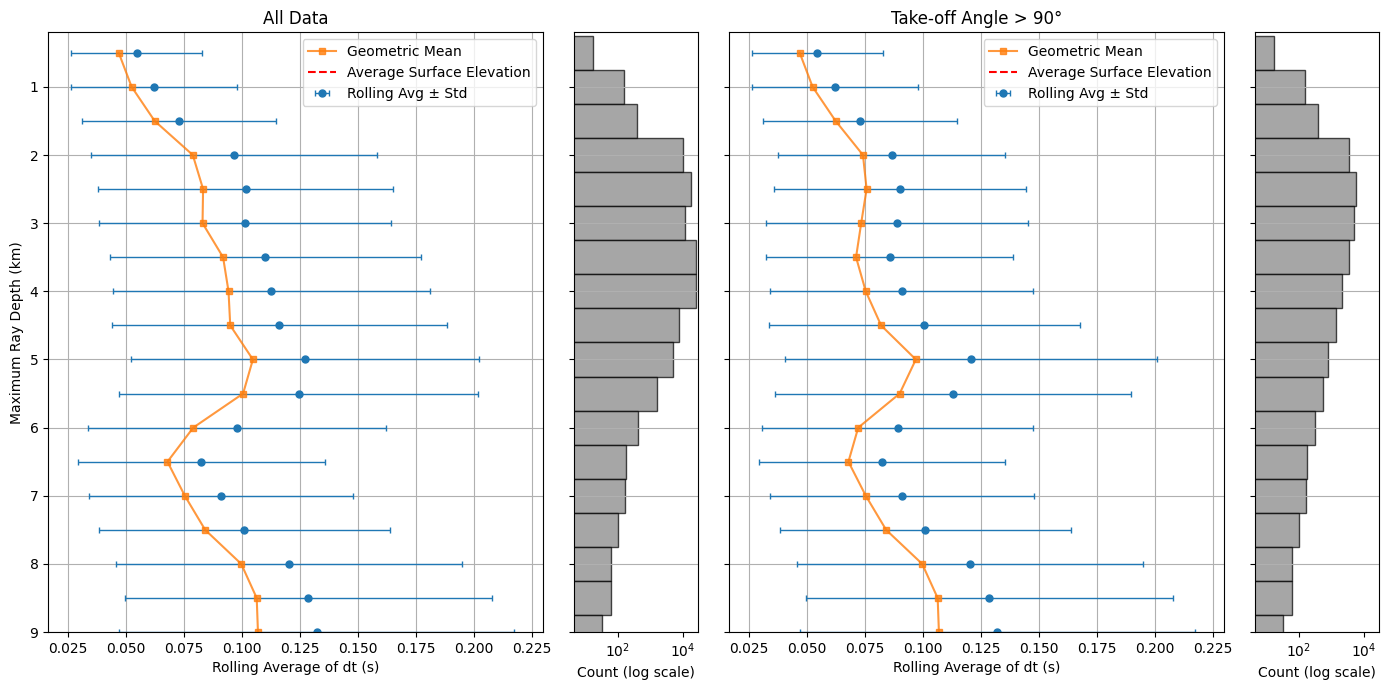

In [6]:

window_width = 1   # window width in km
step = 0.5         # step size for center points in km

# Process for all data
sorted_data = data.sort_values('max_ray_depth_km').reset_index(drop=True)
maxdepth = sorted_data['max_ray_depth_km'].values
tlag = sorted_data['tlag'].values

min_depth = -1
max_depth = 10
window_centers = np.arange(min_depth, max_depth + step, step)

avg_list = []
std_list = []
geo_list = []
center_list = []
count_list = []

for center in window_centers:
    left = center - window_width/2
    right = center + window_width/2
    in_window = (maxdepth >= left) & (maxdepth < right)
    if np.any(in_window):
        tlag_in_window = tlag[in_window]
        avg_list.append(np.nanmean(tlag_in_window))
        std_list.append(np.nanstd(tlag_in_window))
        center_list.append(center)
        count_list.append(np.sum(in_window))
        finite_positive = tlag_in_window[~np.isnan(tlag_in_window) & (tlag_in_window > 0)]
        geo_val = np.nan if len(finite_positive) == 0 else gmean(finite_positive)
        geo_list.append(geo_val)
    else:
        avg_list.append(np.nan)
        std_list.append(np.nan)
        center_list.append(center)
        count_list.append(0)
        geo_list.append(np.nan)

window_df = pd.DataFrame({
    'center': center_list,
    'tlag_avg': avg_list,
    'tlag_std': std_list,
    'tlag_geo': geo_list,
    'n': count_list
})

# Process for data_ninety
sorted_data90 = data_ninety.sort_values('max_ray_depth_km').reset_index(drop=True)
maxdepth_90 = sorted_data90['max_ray_depth_km'].values
tlag_90 = sorted_data90['tlag'].values

min_depth_90 = -1
max_depth_90 = 10
window_centers_90 = np.arange(min_depth_90, max_depth_90 + step, step)

avg_list_90 = []
std_list_90 = []
geo_list_90 = []
center_list_90 = []
count_list_90 = []

for center in window_centers_90:
    left = center - window_width/2
    right = center + window_width/2
    in_window = (maxdepth_90 >= left) & (maxdepth_90 < right)
    if np.any(in_window):
        tlag_in_window = tlag_90[in_window]
        avg_list_90.append(np.nanmean(tlag_in_window))
        std_list_90.append(np.nanstd(tlag_in_window))
        center_list_90.append(center)
        count_list_90.append(np.sum(in_window))
        finite_positive = tlag_in_window[~np.isnan(tlag_in_window) & (tlag_in_window > 0)]
        geo_val = np.nan if len(finite_positive) == 0 else gmean(finite_positive)
        geo_list_90.append(geo_val)
    else:
        avg_list_90.append(np.nan)
        std_list_90.append(np.nan)
        center_list_90.append(center)
        count_list_90.append(0)
        geo_list_90.append(np.nan)

window_df_90 = pd.DataFrame({
    'center': center_list_90,
    'tlag_avg': avg_list_90,
    'tlag_std': std_list_90,
    'tlag_geo': geo_list_90,
    'n': count_list_90
})

# Set up figure: 2 (datasets) x 2 (rolling + count) = 1 row, 4 columns, like Depth_Dependence_1D.ipynb
fig, axes = plt.subplots(1, 4, figsize=(14,7), 
                         gridspec_kw={'width_ratios':[2,0.5,2,0.5]},
                         sharey=True)

ax1, ax2, ax3, ax4 = axes

# Find y-limits to ensure both panels matched, and depth increases downward
min_depth_all = min(np.nanmin(maxdepth), np.nanmin(maxdepth_90))
max_depth_all = max(np.nanmax(maxdepth), np.nanmax(maxdepth_90))
ylims = [max_depth_all, min_depth_all-0.5]  # match logic in original; minimum at top

# Left plot: all data
ax1.errorbar(
    window_df['tlag_avg'], window_df['center'], xerr=window_df['tlag_std'],
    fmt='o', color='tab:blue', ecolor='tab:blue', elinewidth=1, capsize=2, markersize=5, label='Rolling Avg ± Std'
)
ax1.plot(window_df['tlag_geo'], window_df['center'], marker='s', linestyle='-', color='tab:orange', label='Geometric Mean', markersize=5, alpha=0.8)
ax1.axhline(y=-0.65, color='red', linestyle='--', label='Average Surface Elevation')
ax1.set_xlabel('Rolling Average of dt (s)')
ax1.set_ylabel('Maximum Ray Depth (km)')
ax1.set_title('All Data')
ax1.grid(True)
ax1.legend()
ax1.label_outer()
ax1.set_ylim(ylims)

# Beside: Bar plot for count
ax2.barh(window_df['center'], window_df['n'], height=step, color='gray', edgecolor='black', alpha=0.7, log=True)
ax2.axhline(y=-0.65, color='red', linestyle='--')
ax2.set_xlabel('Count (log scale)')
ax2.set_ylabel('')
ax2.set_title('')
ax2.grid(True, axis='y')
ax2.label_outer()
ax2.set_ylim(ylims)
ax2.set_xlim(0, window_df['n'].max() * 1.15)

# Right: data_ninety
ax3.errorbar(
    window_df_90['tlag_avg'], window_df_90['center'], xerr=window_df_90['tlag_std'],
    fmt='o', color='tab:blue', ecolor='tab:blue', elinewidth=1, capsize=2, markersize=5, label='Rolling Avg ± Std'
)
ax3.plot(window_df_90['tlag_geo'], window_df_90['center'], marker='s', linestyle='-', color='tab:orange', label='Geometric Mean', markersize=5, alpha=0.8)
ax3.axhline(y=-0.65, color='red', linestyle='--', label='Average Surface Elevation')
ax3.set_xlabel('Rolling Average of dt (s)')
ax3.set_ylabel('')
ax3.set_title('Take-off Angle > 90°')
ax3.grid(True)
ax3.legend()
ax3.label_outer()
ax3.set_ylim(ylims)

# Beside: Bar plot for count
ax4.barh(window_df_90['center'], window_df_90['n'], height=step, color='gray', edgecolor='black', alpha=0.7, log=True)
ax4.axhline(y=-0.65, color='red', linestyle='--')
ax4.set_xlabel('Count (log scale)')
ax4.set_ylabel('')
ax4.set_title('')
ax4.grid(True, axis='y')
ax4.label_outer()
ax4.set_ylim(ylims)
ax4.set_xlim(ax2.get_xlim())

plt.tight_layout()
plt.savefig('Figure_S3.1.png', dpi=150, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3893357/3745019838.py:137: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0, window_df['n'].max() * 1.15)


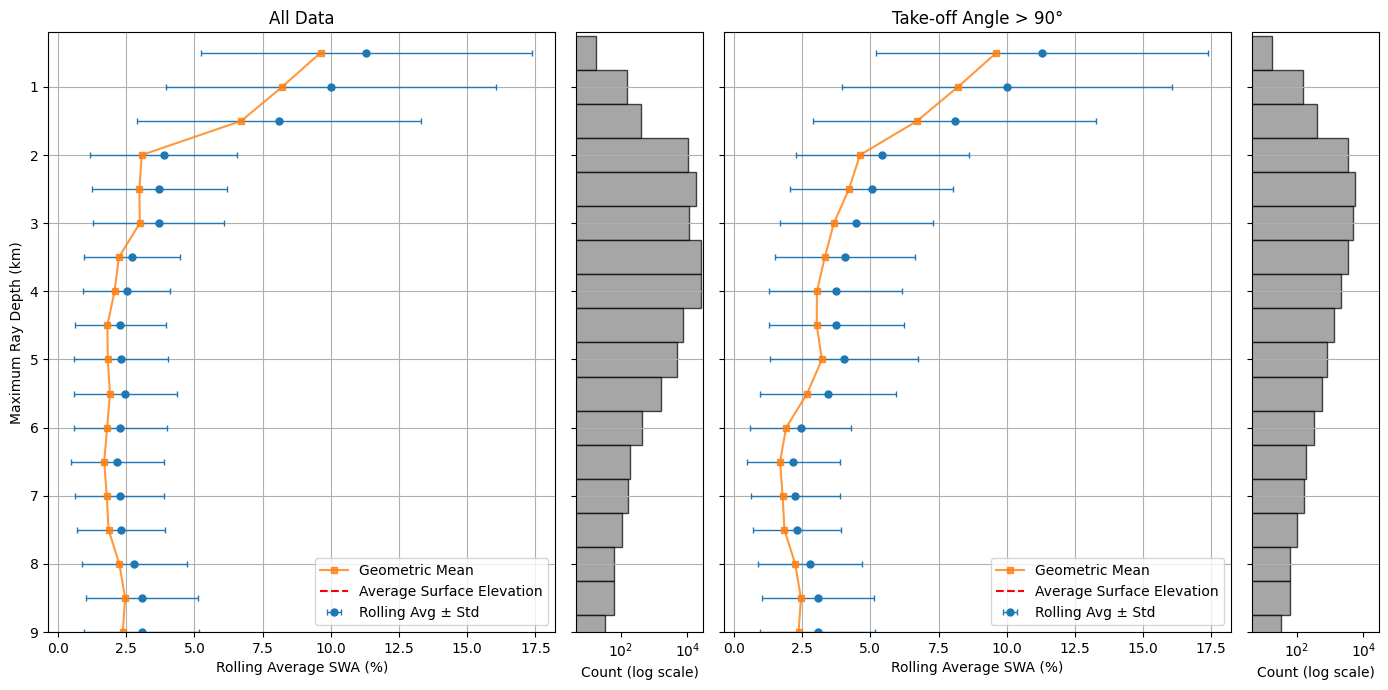

In [7]:
# Compute moving average, geometric mean, and standard deviation over a sliding window in max_ray_depth_km,
# but only every 0.5 km, and each window is 1 km wide; add bar plots of counts as in Depth_Dependence_1D.ipynb.
# Reverse the y-axis so increasing depth points downward.
# This version uses SWA_source_to_station (percentages) instead of tlag.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gmean

window_width = 1   # window width in km
step = 0.5         # step size for center points in km

# Process for all data (using SWA_source_to_station as percentage)
sorted_data = data.sort_values('max_ray_depth_km').reset_index(drop=True)
maxdepth = sorted_data['max_ray_depth_km'].values
swa = sorted_data['SWA_source_to_station'].values  # Percent values

min_depth = -1
max_depth = 10
window_centers = np.arange(min_depth, max_depth + step, step)

avg_list = []
std_list = []
geo_list = []
center_list = []
count_list = []

for center in window_centers:
    left = center - window_width/2
    right = center + window_width/2
    in_window = (maxdepth >= left) & (maxdepth < right)
    if np.any(in_window):
        swa_in_window = swa[in_window]
        avg_list.append(np.nanmean(swa_in_window))
        std_list.append(np.nanstd(swa_in_window))
        center_list.append(center)
        count_list.append(np.sum(in_window))
        finite_positive = swa_in_window[~np.isnan(swa_in_window) & (swa_in_window > 0)]
        geo_val = np.nan if len(finite_positive) == 0 else gmean(finite_positive)
        geo_list.append(geo_val)
    else:
        avg_list.append(np.nan)
        std_list.append(np.nan)
        center_list.append(center)
        count_list.append(0)
        geo_list.append(np.nan)

window_df = pd.DataFrame({
    'center': center_list,
    'swa_avg': avg_list,
    'swa_std': std_list,
    'swa_geo': geo_list,
    'n': count_list
})

# Process for data_ninety (using SWA_source_to_station as percentage)
sorted_data90 = data_ninety.sort_values('max_ray_depth_km').reset_index(drop=True)
maxdepth_90 = sorted_data90['max_ray_depth_km'].values
swa_90 = sorted_data90['SWA_source_to_station'].values  # Percent values

min_depth_90 = -1
max_depth_90 = 10
window_centers_90 = np.arange(min_depth_90, max_depth_90 + step, step)

avg_list_90 = []
std_list_90 = []
geo_list_90 = []
center_list_90 = []
count_list_90 = []

for center in window_centers_90:
    left = center - window_width/2
    right = center + window_width/2
    in_window = (maxdepth_90 >= left) & (maxdepth_90 < right)
    if np.any(in_window):
        swa_in_window = swa_90[in_window]
        avg_list_90.append(np.nanmean(swa_in_window))
        std_list_90.append(np.nanstd(swa_in_window))
        center_list_90.append(center)
        count_list_90.append(np.sum(in_window))
        finite_positive = swa_in_window[~np.isnan(swa_in_window) & (swa_in_window > 0)]
        geo_val = np.nan if len(finite_positive) == 0 else gmean(finite_positive)
        geo_list_90.append(geo_val)
    else:
        avg_list_90.append(np.nan)
        std_list_90.append(np.nan)
        center_list_90.append(center)
        count_list_90.append(0)
        geo_list_90.append(np.nan)

window_df_90 = pd.DataFrame({
    'center': center_list_90,
    'swa_avg': avg_list_90,
    'swa_std': std_list_90,
    'swa_geo': geo_list_90,
    'n': count_list_90
})

# Set up figure: 2 (datasets) x 2 (rolling + count) = 1 row, 4 columns, like Depth_Dependence_1D.ipynb
fig, axes = plt.subplots(1, 4, figsize=(14,7), 
                         gridspec_kw={'width_ratios':[2,0.5,2,0.5]},
                         sharey=True)

ax1, ax2, ax3, ax4 = axes

# Find y-limits to ensure both panels matched, and depth increases downward
min_depth_all = min(np.nanmin(maxdepth), np.nanmin(maxdepth_90))
max_depth_all = max(np.nanmax(maxdepth), np.nanmax(maxdepth_90))
ylims = [max_depth_all, min_depth_all-0.5]  # increasing downward

# Left plot: all data (SWA)
ax1.errorbar(
    window_df['swa_avg'], window_df['center'], xerr=window_df['swa_std'],
    fmt='o', color='tab:blue', ecolor='tab:blue', elinewidth=1, capsize=2, markersize=5, label='Rolling Avg ± Std'
)
ax1.plot(window_df['swa_geo'], window_df['center'], marker='s', linestyle='-', color='tab:orange', label='Geometric Mean', markersize=5, alpha=0.8)
ax1.axhline(y=-0.65, color='red', linestyle='--', label='Average Surface Elevation')
ax1.set_xlabel('Rolling Average SWA (%)')
ax1.set_ylabel('Maximum Ray Depth (km)')
ax1.set_title('All Data')
ax1.grid(True)
ax1.legend()
ax1.label_outer()
ax1.set_ylim(ylims)

# Beside: Bar plot for count
ax2.barh(window_df['center'], window_df['n'], height=step, color='gray', edgecolor='black', alpha=0.7, log=True)
ax2.axhline(y=-0.65, color='red', linestyle='--')
ax2.set_xlabel('Count (log scale)')
ax2.set_ylabel('')
ax2.set_title('')
ax2.grid(True, axis='y')
ax2.label_outer()
ax2.set_ylim(ylims)
ax2.set_xlim(0, window_df['n'].max() * 1.15)

# Right: data_ninety (SWA)
ax3.errorbar(
    window_df_90['swa_avg'], window_df_90['center'], xerr=window_df_90['swa_std'],
    fmt='o', color='tab:blue', ecolor='tab:blue', elinewidth=1, capsize=2, markersize=5, label='Rolling Avg ± Std'
)
ax3.plot(window_df_90['swa_geo'], window_df_90['center'], marker='s', linestyle='-', color='tab:orange', label='Geometric Mean', markersize=5, alpha=0.8)
ax3.axhline(y=-0.65, color='red', linestyle='--', label='Average Surface Elevation')
ax3.set_xlabel('Rolling Average SWA (%)')
ax3.set_ylabel('')
ax3.set_title('Take-off Angle > 90°')
ax3.grid(True)
ax3.legend()
ax3.label_outer()
ax3.set_ylim(ylims)

# Beside: Bar plot for count
ax4.barh(window_df_90['center'], window_df_90['n'], height=step, color='gray', edgecolor='black', alpha=0.7, log=True)
ax4.axhline(y=-0.65, color='red', linestyle='--')
ax4.set_xlabel('Count (log scale)')
ax4.set_ylabel('')
ax4.set_title('')
ax4.grid(True, axis='y')
ax4.label_outer()
ax4.set_ylim(ylims)
ax4.set_xlim(ax2.get_xlim())

plt.tight_layout()
plt.savefig('Figure_S3.2.png', dpi=150, bbox_inches='tight')
plt.show()